<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [113]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
import pandas as pd
import numpy as np

In [115]:
from google.colab import files

uploaded = files.upload()


Saving FitPulse_wearable_device_data.csv to FitPulse_wearable_device_data (1).csv


In [116]:
df

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate,cluster,dbscan_cluster,hr_anomaly,hr_anomaly_rule,hr_predicted,hr_final_anomaly
0,P0001,74.499653,26.0,7.9,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72,0,0,False,False,NaN,False
1,P0002,90.833116,6.0,9.0,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86,0,0,False,False,NaN,False
2,P0003,61.270774,40.0,8.6,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63,1,0,False,False,75.822718,False
3,P0005,59.807869,29.0,8.6,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91,0,0,False,False,75.620747,False
4,P0006,92.702179,34.0,8.4,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93,1,0,False,False,73.172440,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7903,P8667,77.757809,22.0,8.4,2025-01-20 21:50:00,62,169,M,41,2360,8.4,9792,92,0,0,False,False,75.738763,False
7904,P8668,62.973343,8.0,7.9,2025-01-19 00:35:00,88,163,M,26,2965,7.9,9876,87,0,0,False,False,74.304770,False
7905,P8669,86.473075,43.0,7.4,2025-01-19 17:10:00,77,163,F,25,2127,7.4,9526,97,0,0,False,False,71.009186,False
7906,P8670,66.679417,10.0,7.9,2025-01-03 23:40:00,68,175,F,53,1830,7.9,9543,67,1,0,False,False,NaN,False


In [117]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df = df.sort_values(['Patient_ID', 'time_stamp'])

In [118]:
from tsfresh import extract_features
import pandas as pd # Ensure pandas is imported for pd.to_numeric and mean()

# First, ensure 'sleep_tracking' is numeric (if it might have been strings like 'sleep')
df['sleep_tracking'] = pd.to_numeric(df['sleep_tracking'], errors='coerce')

# Fill NaN in 'sleep_tracking' with 'daily_sleep_hours' for the corresponding row
df['sleep_tracking'] = df['sleep_tracking'].fillna(df['daily_sleep_hours'])

# If there are still NaNs (e.g., if 'daily_sleep_hours' was also NaN for some rows),
# fill them with the mean of 'daily_sleep_hours' to ensure no NaNs remain.
if df['sleep_tracking'].isnull().any():
    mean_daily_sleep = df['daily_sleep_hours'].mean()
    df['sleep_tracking'] = df['sleep_tracking'].fillna(mean_daily_sleep)

# Define the list of actual numerical time-series measurement columns
tsfresh_measurement_columns = [
    'heart_rate', 'step_count', 'sleep_tracking', 'Weight', 'Height', 'age',
    'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate'
]

# Create a copy of df with only the necessary columns for tsfresh
# This includes the id, sort column, and the measurement columns
df_tsfresh_input = df[['Patient_ID', 'time_stamp'] + tsfresh_measurement_columns].copy()

# Limit to first 100 rows for quicker feature extraction during testing
df_tsfresh_input = df_tsfresh_input.head(100)

tsfresh_df = extract_features(
    df_tsfresh_input,
    column_id='Patient_ID',
    column_sort='time_stamp',
    default_fc_parameters=None # Let tsfresh infer value columns from df_tsfresh_input
)

print(f"Shape of tsfresh_df: {tsfresh_df.shape}")

Feature Extraction: 100%|██████████| 1000/1000 [01:32<00:00, 10.82it/s]


Shape of tsfresh_df: (100, 7830)


In [149]:
import pandas as pd
import numpy as np
!pip install prophet plotly scikit-learn

In [120]:
df=pd.read_csv('/content/drive/MyDrive/FitPulse Health Anomaly Detection from Fitness Devices/FitPulse_final_dataset.csv')

In [121]:
df['time_stamp'] = pd.to_datetime(df['time_stamp'])
df = df.sort_values(['Patient_ID', 'time_stamp'])

In [122]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical columns from the original df for clustering
df_features_for_clustering = df[['heart_rate', 'step_count', 'sleep_tracking', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].copy()

# Handle potential NaN values in these features by filling with 0 or mean/median
# For simplicity, let's fill with 0, but a more robust strategy might be needed based on data distribution.
df_features_for_clustering = df_features_for_clustering.fillna(0)

X = df_features_for_clustering.values
X_scaled = StandardScaler().fit_transform(X)

In [123]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
# Apply KMeans directly to the scaled numerical features from the original df
df['cluster'] = kmeans.fit_predict(X_scaled)

In [124]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=10)
# Apply DBSCAN directly to the scaled numerical features from the original df
df['dbscan_cluster'] = db.fit_predict(X_scaled)

In [125]:
tsfresh_df = tsfresh_df.fillna(0)

In [126]:
from prophet import Prophet

def run_prophet(df, value_col):
    temp = df[['time_stamp', value_col]].rename(
        columns={'time_stamp': 'ds', value_col: 'y'}
    )

    # Drop rows where 'y' (value_col) is NaN, as Prophet cannot handle them.
    temp.dropna(subset=['y'], inplace=True)

    # Prophet requires at least 2 data points for fitting.
    if len(temp) < 2:
        print(f"Patient {df['Patient_ID'].iloc[0]} has less than 2 non-NaN data points for '{value_col}'. Skipping Prophet modeling.")
        return None

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model.fit(temp)
    forecast = model.predict(temp)

    return forecast

In [127]:
patient_counts = df['Patient_ID'].value_counts()
eligible_patient_id = None
# Prophet generally requires a good amount of data to detect seasonality and trends.
# A common recommendation is at least several weeks or months of data.
# We'll set a higher threshold for `eligible_patient_id` to ensure more robust modeling.
# For example, let's aim for at least 30 observations.
for patient_id, count in patient_counts.items():
    if count >= 30: # Changed from 2 to 30 to ensure sufficient data for Prophet
        eligible_patient_id = patient_id
        break

if eligible_patient_id:
    print(f"Using Patient_ID: {eligible_patient_id} for Prophet modeling.")
    prophet_steps = run_prophet(df[df['Patient_ID'] == eligible_patient_id], 'daily_steps')
    prophet_hr = run_prophet(df[df['Patient_ID'] == eligible_patient_id], 'resting_heart_rate')
else:
    print("No patient has at least 30 data points for time series analysis using Prophet. Prophet modeling for individual patients cannot proceed with this dataset.")
    prophet_steps = None
    prophet_hr = None

No patient has at least 30 data points for time series analysis using Prophet. Prophet modeling for individual patients cannot proceed with this dataset.


In [128]:
from sklearn.preprocessing import StandardScaler

# Select relevant numerical columns from the original df for clustering
df_features_for_clustering = df[['heart_rate', 'step_count', 'sleep_tracking', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].copy()

# Handle potential NaN values in these features by filling with 0 or mean/median
# For simplicity, let's fill with 0, but a more robust strategy might be needed based on data distribution.
df_features_for_clustering = df_features_for_clustering.fillna(0)

X = df_features_for_clustering.values
X_scaled = StandardScaler().fit_transform(X)

In [129]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init to suppress warning
# Apply KMeans directly to the scaled numerical features from the original df
df['cluster'] = kmeans.fit_predict(X_scaled)

In [130]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2.0, min_samples=10)
# Apply DBSCAN directly to the scaled numerical features from the original df
df['dbscan_cluster'] = db.fit_predict(X_scaled)

In [131]:
from prophet import Prophet

def prophet_model(df, col):
    temp = df[['timestamp', col]].rename(
        columns={'timestamp': 'ds', col: 'y'}
    )

    model = Prophet(daily_seasonality=True)
    model.fit(temp)
    return model.predict(temp)


In [132]:
user_id = 'P0001' # Changed to a string as Patient_ID seems to be string type
user_df = df[df['Patient_ID'] == user_id].copy()
user_df = user_df.sort_values('time_stamp')

In [133]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['time_stamp', value_col]].rename(
        columns={'time_stamp': 'ds', value_col: 'y'}
    )

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast

In [134]:
# First, ensure 'time_stamp' is in datetime format and set it as index
df_agg_time = df.set_index('time_stamp')

# Resample the data daily and calculate the mean of numerical columns
# We exclude 'Patient_ID' and 'gender' as they are not numerical for mean aggregation
# We also exclude 'sleep_tracking' which is mostly NaN and was filled with 0, so its mean might not be representative in this aggregated context.
# For 'sleep_tracking', if it contained meaningful values, a different aggregation like sum or count might be more appropriate.
aggregated_daily_df = df_agg_time.resample('D')[['heart_rate', 'step_count', 'Weight', 'Height', 'age', 'daily_calories', 'daily_sleep_hours', 'daily_steps', 'resting_heart_rate']].mean()

display(aggregated_daily_df.head())

,heart_rate,step_count,Weight,Height,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
time_stamp,,,,,,,,,
2025-01-01,72.291992,28.896552,69.406130,170.260536,41.704981,2238.957854,8.070115,9106.735632,80.107280
2025-01-02,71.668099,25.652985,69.608209,169.664179,42.921642,2259.201493,8.134328,8920.074627,80.231343
2025-01-03,72.638052,24.524345,69.224719,169.423221,40.985019,2239.543071,8.098127,9004.812734,79.880150
2025-01-04,72.234466,25.244094,70.755906,167.783465,44.157480,2270.732283,8.014961,8811.090551,79.393701
2025-01-05,71.974136,23.501946,70.307393,169.941634,43.272374,2266.501946,8.019455,8849.276265,82.027237


In [135]:
from prophet import Prophet

# Prepare the aggregated data for Prophet
prophet_input_df = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'heart_rate': 'y'})

# Drop any rows where 'y' is NaN after aggregation
prophet_input_df.dropna(subset=['y'], inplace=True)

# Check if there's enough data for Prophet
if len(prophet_input_df) < 2:
    print("Not enough daily aggregated data points for Prophet modeling.")
else:
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model.fit(prophet_input_df)
    future = model.make_future_dataframe(periods=7) # Forecast for the next 7 days
    forecast = model.predict(future)

    print("Prophet forecast for aggregated daily heart rate:")
    display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast for aggregated daily heart rate:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,74.128006,70.368507,78.114602
1,2025-01-02,71.598245,67.673636,75.603612
2,2025-01-03,69.736829,65.877218,73.404517
3,2025-01-04,72.293004,68.343575,76.422592
4,2025-01-05,71.857270,68.142261,75.699131


In [136]:
patients_with_more_than_2_data_points = patient_counts[patient_counts > 2]
print(f"Patients with more than 2 data points: {list(patients_with_more_than_2_data_points.index)}")

Patients with more than 2 data points: []


In [137]:
from prophet import Prophet

def prophet_model(df, value_col):
    temp = df[['timestamp', value_col]].rename(
        columns={'timestamp': 'ds', value_col: 'y'}
    )

    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )

    model.fit(temp)
    forecast = model.predict(temp)

    # Merge actual values back
    forecast = forecast.merge(
        temp[['ds', 'y']],
        on='ds',
        how='left'
    )

    return forecast


In [138]:
from prophet import Prophet
import pandas as pd

df_prophet = df.rename(columns={
    "time_stamp": "ds",
    "resting_heart_rate": "y"
})

df_prophet["ds"] = pd.to_datetime(df_prophet["ds"]).dt.tz_localize(None)

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=10, freq="T")
forecast = model.predict(future)

forecast = forecast.merge(
    df_prophet[['ds', 'y']],
    on='ds',
    how='left'
)

forecast['residual'] = forecast['y'] - forecast['yhat']

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates = pd.date_range(


In [139]:
import pandas as pd

# Identify rows where all relevant columns are NaN
# We can check for NaNs in any one column, as we know they all have the same count of NaNs
dates_with_missing_values = aggregated_daily_df[aggregated_daily_df['heart_rate'].isna()].index

print(f"Number of dates with missing values: {len(dates_with_missing_values)}")
print("Dates with missing values (first 10 if many):\n")
for date in dates_with_missing_values.to_list()[:10]:
    print(date.strftime('%Y-%m-%d'))

if len(dates_with_missing_values) > 10:
    print(f"\n... and {len(dates_with_missing_values) - 10} more dates.")

Number of dates with missing values: 297
Dates with missing values (first 10 if many):

2025-02-02
2025-02-03
2025-02-04
2025-02-05
2025-02-06
2025-02-07
2025-02-08
2025-02-09
2025-02-10
2025-02-11

... and 287 more dates.


In [140]:
print("Missing values in aggregated_daily_df:")
display(aggregated_daily_df.isna().sum())

Missing values in aggregated_daily_df:


,0
heart_rate,297
step_count,297
Weight,297
Height,297
age,297
daily_calories,297
daily_sleep_hours,297
daily_steps,297
resting_heart_rate,297


In [141]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Prepare the aggregated data for Prophet using 'daily_steps'
prophet_input_df_steps = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'daily_steps': 'y'})

# Drop any rows where 'y' (daily_steps) is NaN after aggregation
prophet_input_df_steps.dropna(subset=['y'], inplace=True)

# Check if there's enough data for Prophet
if len(prophet_input_df_steps) < 2:
    print("Not enough daily aggregated data points for Prophet modeling for daily_steps.")
else:
    model_steps = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model_steps.fit(prophet_input_df_steps)
    future_steps = model_steps.make_future_dataframe(periods=7) # Forecast for the next 7 days
    forecast_steps = model_steps.predict(future_steps)

    print("Prophet forecast for aggregated daily steps:")
    display(forecast_steps[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast for aggregated daily steps:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,9036.089202,8390.038863,9717.540296
1,2025-01-02,8900.526667,8253.178572,9567.766130
2,2025-01-03,9146.860243,8485.722939,9812.697193
3,2025-01-04,8164.262166,7535.739609,8807.311508
4,2025-01-05,8894.661557,8197.995795,9556.800684


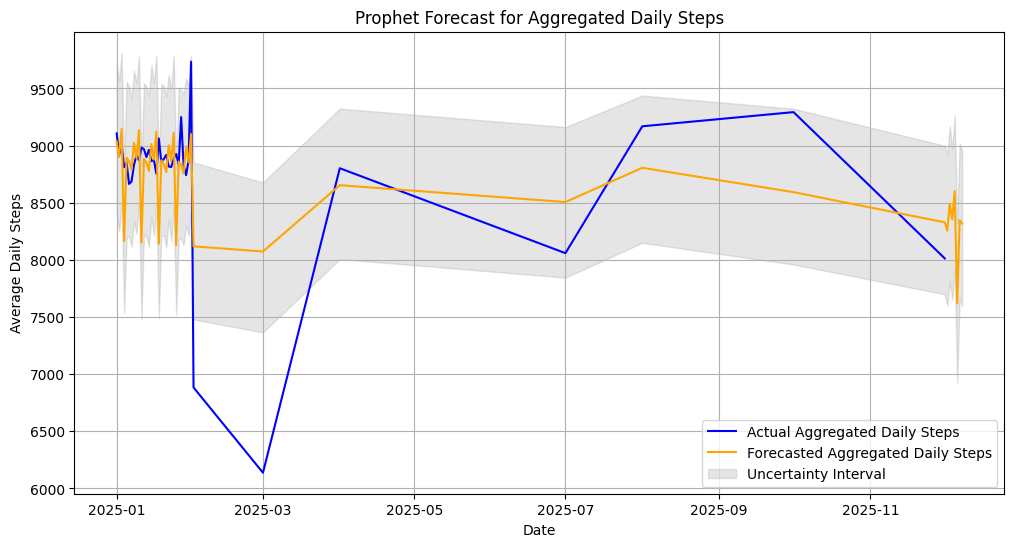

In [142]:
import matplotlib.pyplot as plt

# Plot the Prophet forecast for aggregated daily steps
plt.figure(figsize=(12, 6))
plt.plot(prophet_input_df_steps['ds'], prophet_input_df_steps['y'], label='Actual Aggregated Daily Steps', color='blue')
plt.plot(forecast_steps['ds'], forecast_steps['yhat'], label='Forecasted Aggregated Daily Steps', color='orange')
plt.fill_between(forecast_steps['ds'], forecast_steps['yhat_lower'], forecast_steps['yhat_upper'], color='gray', alpha=0.2, label='Uncertainty Interval')
plt.title('Prophet Forecast for Aggregated Daily Steps')
plt.xlabel('Date')
plt.ylabel('Average Daily Steps')
plt.legend()
plt.grid(True)
plt.show()

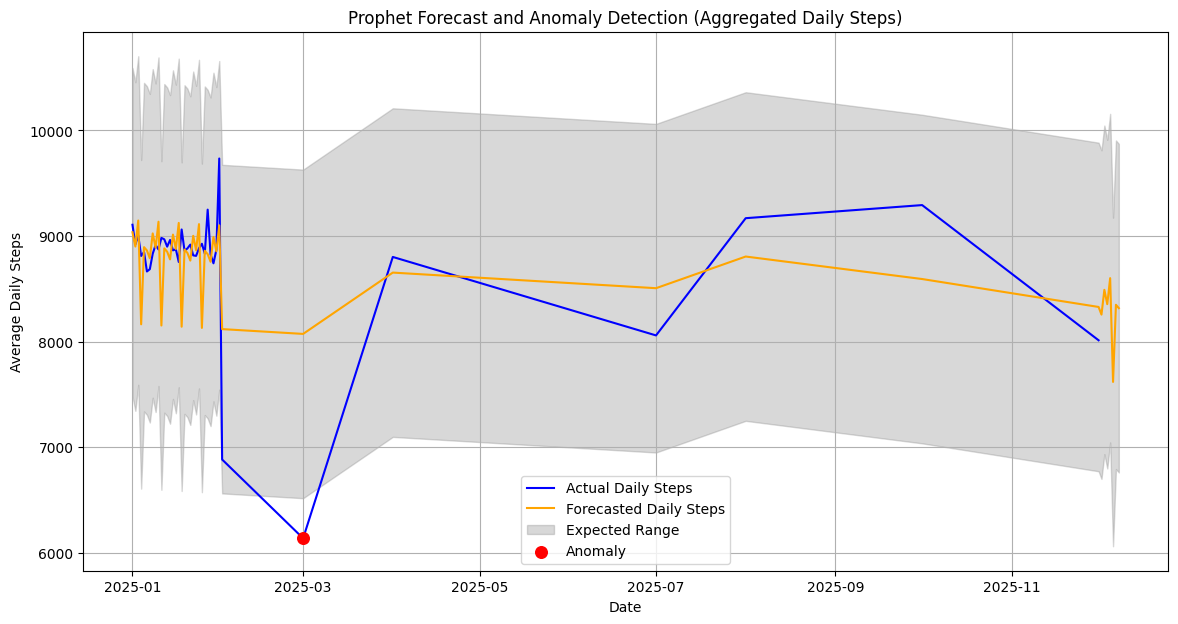

Saved daily_steps_anomalies.png


In [143]:
import matplotlib.pyplot as plt

# Ensure forecast_with_actuals_steps and anomalies_steps are defined
# (These are typically created in cell '2da44256')

plt.figure(figsize=(14, 7))
plt.plot(forecast_with_actuals_steps['ds'], forecast_with_actuals_steps['y'], label='Actual Daily Steps', color='blue')
plt.plot(forecast_with_actuals_steps['ds'], forecast_with_actuals_steps['yhat'], label='Forecasted Daily Steps', color='orange')
plt.fill_between(
    forecast_with_actuals_steps['ds'],
    forecast_with_actuals_steps['lower_threshold'],
    forecast_with_actuals_steps['upper_threshold'],
    alpha=0.3,
    color='gray',
    label='Expected Range'
)

if not anomalies_steps.empty:
    plt.scatter(
        anomalies_steps['ds'],
        anomalies_steps['y'],
        color='red',
        label='Anomaly',
        marker='o',
        s=70,
        zorder=5
    )

plt.title('Prophet Forecast and Anomaly Detection (Aggregated Daily Steps)')
plt.xlabel('Date')
plt.ylabel('Average Daily Steps')
plt.legend()
plt.grid(True)
plt.savefig('daily_steps_anomalies.png')
plt.show()
print("Saved daily_steps_anomalies.png")

Standard Deviation of Residuals for daily_steps: 518.54


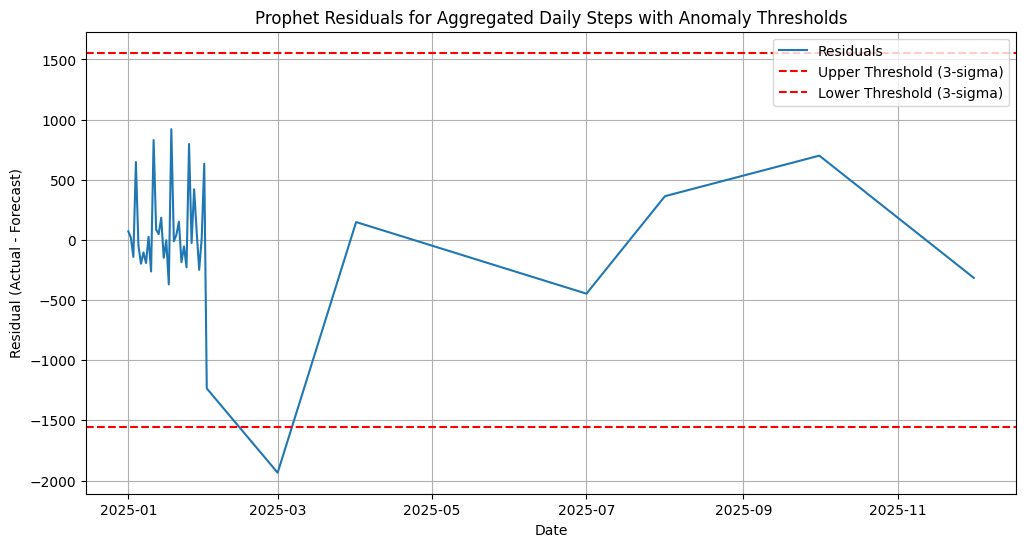


Potential Anomalies Detected for daily_steps:


,ds,y,yhat,residual,upper_threshold,lower_threshold
32,2025-03-01,6138.0,8073.338785,-1935.338785,9628.958831,6517.718738


In [144]:
# Calculate residuals and identify anomalies for daily_steps
forecast_with_actuals_steps = forecast_steps.merge(
    prophet_input_df_steps[['ds', 'y']],
    on='ds',
    how='left'
)

forecast_with_actuals_steps['residual'] = forecast_with_actuals_steps['y'] - forecast_with_actuals_steps['yhat']
residual_std_steps = forecast_with_actuals_steps['residual'].std()

# Define anomaly thresholds (e.g., 3 standard deviations from the mean residual)
forecast_with_actuals_steps['upper_threshold'] = forecast_with_actuals_steps['yhat'] + 3 * residual_std_steps
forecast_with_actuals_steps['lower_threshold'] = forecast_with_actuals_steps['yhat'] - 3 * residual_std_steps

print(f"Standard Deviation of Residuals for daily_steps: {residual_std_steps:.2f}")

# Plot the residuals for daily_steps
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(forecast_with_actuals_steps['ds'], forecast_with_actuals_steps['residual'], label='Residuals')
plt.axhline(y=3 * residual_std_steps, color='r', linestyle='--', label='Upper Threshold (3-sigma)')
plt.axhline(y=-3 * residual_std_steps, color='r', linestyle='--', label='Lower Threshold (3-sigma)')
plt.title('Prophet Residuals for Aggregated Daily Steps with Anomaly Thresholds')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.legend()
plt.grid(True)
plt.show()

# Identify potential anomalies for daily_steps
anomalies_steps = forecast_with_actuals_steps[
    ((forecast_with_actuals_steps['residual'] > 3 * residual_std_steps) |
     (forecast_with_actuals_steps['residual'] < -3 * residual_std_steps)) |
    ((forecast_with_actuals_steps['y'] < 4000) | (forecast_with_actuals_steps['y'] > 10000)) # New conditions for step count range
]

if not anomalies_steps.empty:
    print("\nPotential Anomalies Detected for daily_steps:")
    display(anomalies_steps[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
else:
    print("\nNo significant anomalies detected for daily_steps based on 3-sigma threshold and 4k-10k step range.")

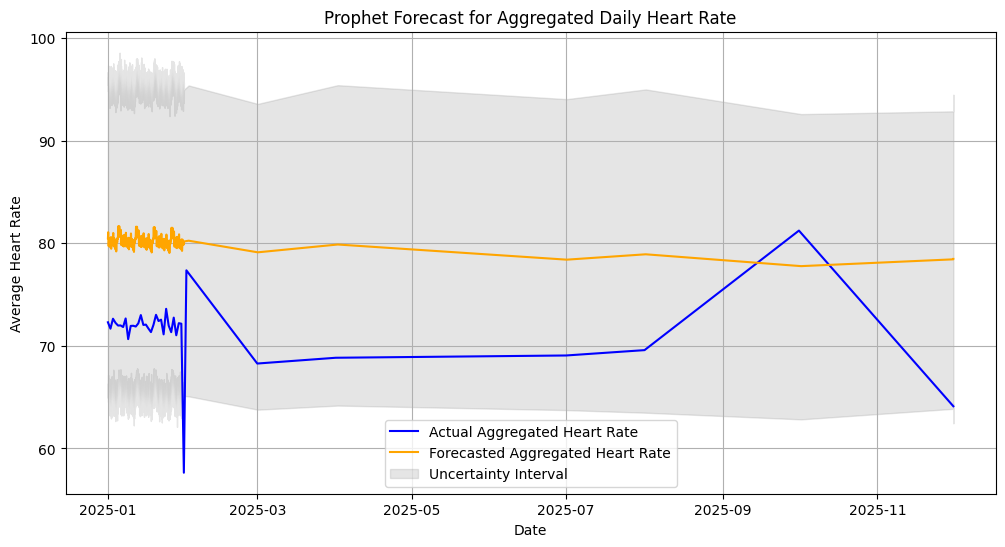

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(prophet_input_df['ds'], prophet_input_df['y'], label='Actual Aggregated Heart Rate', color='blue')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecasted Aggregated Heart Rate', color='orange')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='gray', alpha=0.2, label='Uncertainty Interval')
plt.title('Prophet Forecast for Aggregated Daily Heart Rate')
plt.xlabel('Date')
plt.ylabel('Average Heart Rate')
plt.legend()
plt.grid(True)
plt.show()

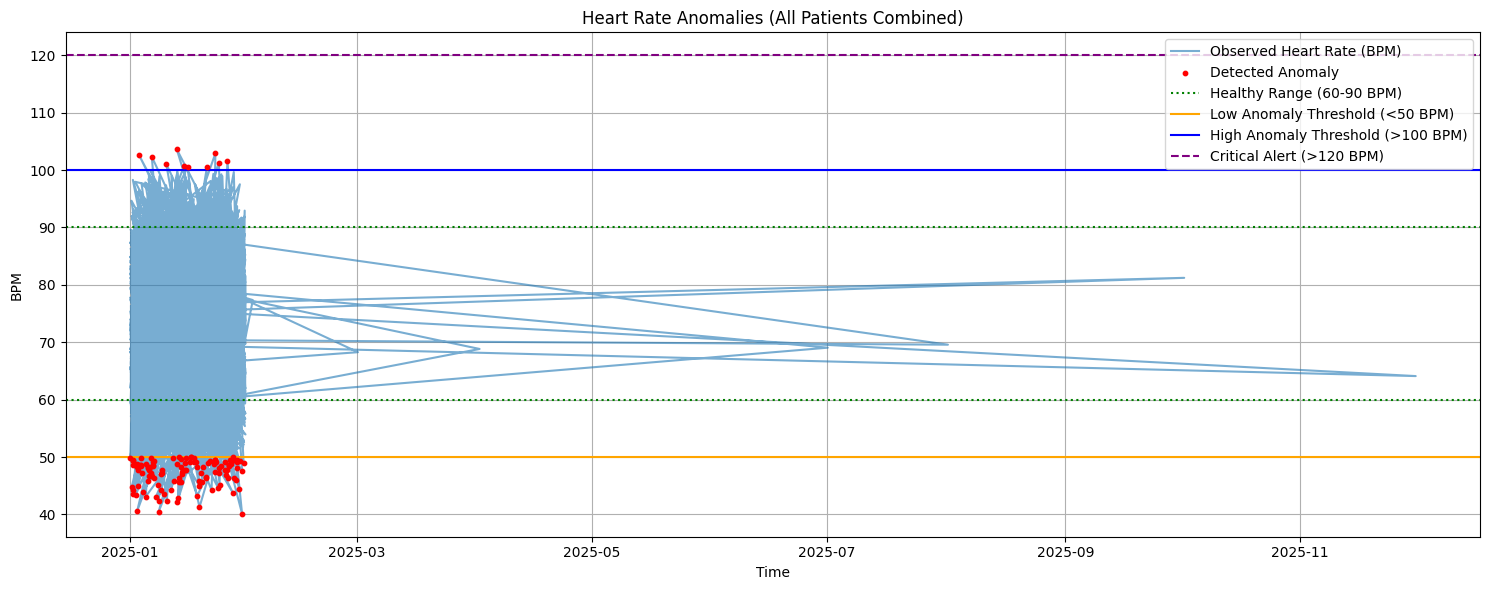

In [146]:
import os
import matplotlib.pyplot as plt

df["hr_anomaly"] = (df["heart_rate"] < 50) | (df["heart_rate"] > 100) # Anomaly condition (Low <50, High >100)

plt.figure(figsize=(15,6))
plt.plot(df["time_stamp"], df["heart_rate"], label="Observed Heart Rate (BPM)", alpha=0.6)
plt.scatter(
    df[df["hr_anomaly"]]["time_stamp"],
    df[df["hr_anomaly"]]["heart_rate"],
    color="red",
    label="Detected Anomaly",
    s=10, # Smaller size for individual anomalies in a large dataset
    zorder=5
)

plt.axhline(60, linestyle=":", color='green', label='Healthy Range (60-90 BPM)')
plt.axhline(90, linestyle=":", color='green')
plt.axhline(50, linestyle="-", color='orange', label='Low Anomaly Threshold (<50 BPM)')
plt.axhline(100, linestyle="-", color='blue', label='High Anomaly Threshold (>100 BPM)')
plt.axhline(120, linestyle="--", color='purple', label='Critical Alert (>120 BPM)')

plt.title("Heart Rate Anomalies (All Patients Combined)")
plt.xlabel("Time")
plt.ylabel("BPM")
plt.legend()
plt.grid(True)
plt.tight_layout()

os.makedirs('visualizations', exist_ok=True)
plt.savefig("visualizations/heart_rate_anomalies.png")
plt.show()

In [167]:
prophet_input_df = df[['time_stamp', 'heart_rate']].rename(
    columns={'time_stamp': 'ds', 'heart_rate': 'y'}
)


Standard Deviation of Residuals for aggregated heart rate: 3.10


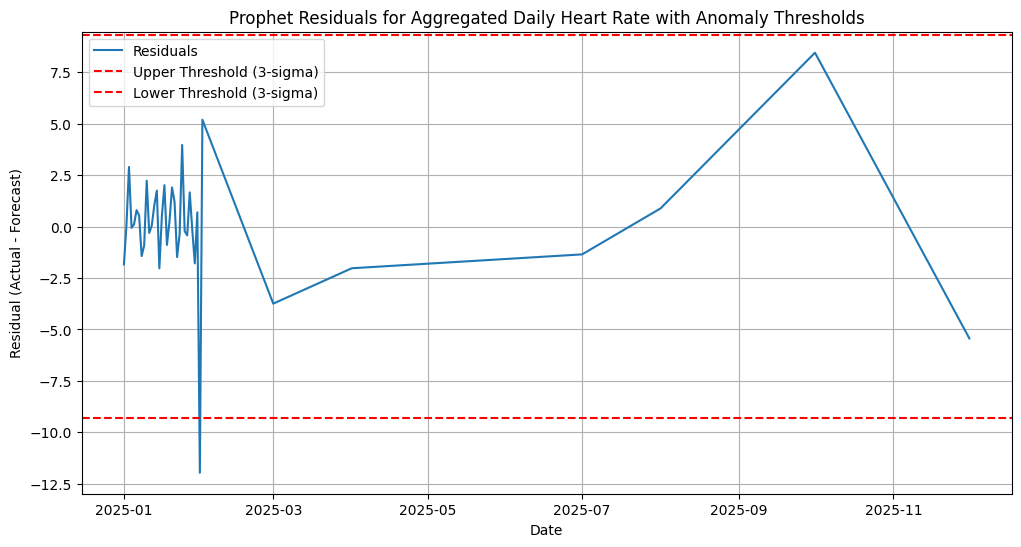


Potential Anomalies Detected:


,ds,y,yhat,residual,upper_threshold,lower_threshold
30,2025-01-31,57.634601,69.597484,-11.962883,78.902323,60.292646


In [193]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported for DataFrame operations
from prophet import Prophet # Import Prophet

# Re-create prophet_input_df for aggregated heart rate to ensure correct 'y' column
# This assumes 'aggregated_daily_df' is available from previous execution.
prophet_input_df_agg_hr = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'heart_rate': 'y'})

# Drop any rows where 'y' is NaN after aggregation
prophet_input_df_agg_hr.dropna(subset=['y'], inplace=True)

# Check if there's enough data for Prophet
if len(prophet_input_df_agg_hr) < 2:
    print("Not enough daily aggregated data points for Prophet modeling for heart rate.")
    # If not enough data, we can't proceed with Prophet for this metric.
    # We might want to exit this block or set flags to prevent further errors.
else:
    # Re-run Prophet model for aggregated daily heart rate to get the correct forecast
    # This forecast will be consistent with prophet_input_df_agg_hr
    model_agg_hr = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False # Disabling yearly seasonality due to potentially sparse data
    )

    model_agg_hr.fit(prophet_input_df_agg_hr)
    future_agg_hr = model_agg_hr.make_future_dataframe(periods=7) # Forecast for the next 7 days
    forecast_agg_hr = model_agg_hr.predict(future_agg_hr)

    # Now, merge the forecast predictions with the actual aggregated heart rate values
    # Use forecast_agg_hr and prophet_input_df_agg_hr for this
    forecast_with_actuals = forecast_agg_hr.merge(
        prophet_input_df_agg_hr[['ds', 'y']], # Use 'y' from the aggregated heart rate data
        on='ds',
        how='left'
    )

    # Calculate residuals and identify anomalies
    # This part can proceed as originally intended, now that 'y' is correctly merged
    forecast_with_actuals['residual'] = forecast_with_actuals['y'] - forecast_with_actuals['yhat']
    residual_std = forecast_with_actuals['residual'].std()

    # Define anomaly thresholds (e.g., 3 standard deviations from the mean residual)
    forecast_with_actuals['upper_threshold'] = forecast_with_actuals['yhat'] + 3 * residual_std
    forecast_with_actuals['lower_threshold'] = forecast_with_actuals['yhat'] - 3 * residual_std

    print(f"Standard Deviation of Residuals for aggregated heart rate: {residual_std:.2f}")

    # Plot the residuals
    plt.figure(figsize=(12, 6))
    plt.plot(forecast_with_actuals['ds'], forecast_with_actuals['residual'], label='Residuals')
    plt.axhline(y=3 * residual_std, color='r', linestyle='--', label='Upper Threshold (3-sigma)')
    plt.axhline(y=-3 * residual_std, color='r', linestyle='--', label='Lower Threshold (3-sigma)')
    plt.title('Prophet Residuals for Aggregated Daily Heart Rate with Anomaly Thresholds')
    plt.xlabel('Date')
    plt.ylabel('Residual (Actual - Forecast)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Identify potential anomalies based on both statistical thresholds and biological range
    anomalies = forecast_with_actuals[
        ((forecast_with_actuals['residual'] > 3 * residual_std) |
         (forecast_with_actuals['residual'] < -3 * residual_std)) |
        ((forecast_with_actuals['y'] < 50) | (forecast_with_actuals['y'] > 100)) # Updated condition for heart rate range
    ]

    if not anomalies.empty:
        print("\nPotential Anomalies Detected:")
        display(anomalies[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
    else:
        print("\nNo significant anomalies detected based on 3-sigma threshold and 50-100 BPM range.")


In [151]:
print("--- Info for 'forecast' DataFrame before merge ---")
forecast.info()
print("\n--- Head of 'forecast' DataFrame before merge ---")
display(forecast.head())

print("\n--- Info for 'prophet_input_df' DataFrame before merge ---")
prophet_input_df.info()
print("\n--- Head of 'prophet_input_df' DataFrame before merge ---")
display(prophet_input_df.head())

# Check if 'y' exists in prophet_input_df
if 'y' in prophet_input_df.columns:
    print("\n'y' column exists in prophet_input_df.")
else:
    print("\nWARNING: 'y' column does NOT exist in prophet_input_df. This is problematic.")

--- Info for 'forecast' DataFrame before merge ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          7919 non-null   datetime64[ns]
 1   trend                       7919 non-null   float64       
 2   yhat_lower                  7919 non-null   float64       
 3   yhat_upper                  7919 non-null   float64       
 4   trend_lower                 7919 non-null   float64       
 5   trend_upper                 7919 non-null   float64       
 6   additive_terms              7919 non-null   float64       
 7   additive_terms_lower        7919 non-null   float64       
 8   additive_terms_upper        7919 non-null   float64       
 9   daily                       7919 non-null   float64       
 10  daily_lower                 7919 non-null   float64       
 11  daily

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,y,residual
0,2025-01-01 00:00:00,80.337347,65.789609,94.455122,80.337347,80.337347,0.136479,0.136479,0.136479,-0.012220,...,-0.012220,0.148699,0.148699,0.148699,0.0,0.0,0.0,80.473826,86.0,5.526174
1,2025-01-01 00:05:00,80.337321,65.265298,95.483228,80.337321,80.337321,0.163726,0.163726,0.163726,0.016685,...,0.016685,0.147041,0.147041,0.147041,0.0,0.0,0.0,80.501047,66.0,-14.501047
2,2025-01-01 00:10:00,80.337296,66.267613,96.700298,80.337296,80.337296,0.191656,0.191656,0.191656,0.046297,...,0.046297,0.145359,0.145359,0.145359,0.0,0.0,0.0,80.528951,98.0,17.471049
3,2025-01-01 00:15:00,80.337270,65.660537,96.689825,80.337270,80.337270,0.220147,0.220147,0.220147,0.076494,...,0.076494,0.143653,0.143653,0.143653,0.0,0.0,0.0,80.557417,83.0,2.442583
4,2025-01-01 00:20:00,80.337245,64.904522,95.390176,80.337245,80.337245,0.249075,0.249075,0.249075,0.107151,...,0.107151,0.141924,0.141924,0.141924,0.0,0.0,0.0,80.586320,86.0,5.413680



--- Info for 'prophet_input_df' DataFrame before merge ---
<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 334
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ds                  38 non-null     datetime64[ns]
 1   y                   38 non-null     float64       
 2   step_count          38 non-null     float64       
 3   Weight              38 non-null     float64       
 4   Height              38 non-null     float64       
 5   age                 38 non-null     float64       
 6   daily_calories      38 non-null     float64       
 7   daily_sleep_hours   38 non-null     float64       
 8   daily_steps         38 non-null     float64       
 9   resting_heart_rate  38 non-null     float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 3.3 KB

--- Head of 'prophet_input_df' DataFrame before merge ---


,ds,y,step_count,Weight,Height,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,2025-01-01,72.291992,28.896552,69.406130,170.260536,41.704981,2238.957854,8.070115,9106.735632,80.107280
1,2025-01-02,71.668099,25.652985,69.608209,169.664179,42.921642,2259.201493,8.134328,8920.074627,80.231343
2,2025-01-03,72.638052,24.524345,69.224719,169.423221,40.985019,2239.543071,8.098127,9004.812734,79.880150
3,2025-01-04,72.234466,25.244094,70.755906,167.783465,44.157480,2270.732283,8.014961,8811.090551,79.393701
4,2025-01-05,71.974136,23.501946,70.307393,169.941634,43.272374,2266.501946,8.019455,8849.276265,82.027237



'y' column exists in prophet_input_df.


In [172]:
if 'forecast' in locals() and not forecast.empty:
    print("First 5 'ds' values in the current 'forecast' DataFrame:")
    display(forecast['ds'].head())
else:
    print("The 'forecast' DataFrame is not defined or is empty.")

First 5 'ds' values in the current 'forecast' DataFrame:


,ds
0,2025-01-01 00:00:00
1,2025-01-01 00:05:00
2,2025-01-01 00:10:00
3,2025-01-01 00:15:00
4,2025-01-01 00:20:00


In [173]:
if 'prophet_input_df' in locals() and not prophet_input_df.empty:
    print("First 5 'ds' values in 'prophet_input_df' DataFrame:")
    display(prophet_input_df['ds'].head())
else:
    print("The 'prophet_input_df' DataFrame is not defined or is empty.")

First 5 'ds' values in 'prophet_input_df' DataFrame:


,ds
0,2025-01-14 16:50:00
1,2025-01-21 08:55:00
2,2025-01-17 07:10:00
3,2025-01-18 18:25:00
4,2025-01-13 07:20:00


In [174]:
if 'y' in forecast.columns:
    print("The 'y' column exists in the 'forecast' DataFrame.")
else:
    print("The 'y' column does NOT exist in the 'forecast' DataFrame.")

The 'y' column exists in the 'forecast' DataFrame.


In [175]:
residual_std = forecast['residual'].std()

forecast['upper_threshold'] = forecast['yhat'] + 3 * residual_std
forecast['lower_threshold'] = forecast['yhat'] - 3 * residual_std


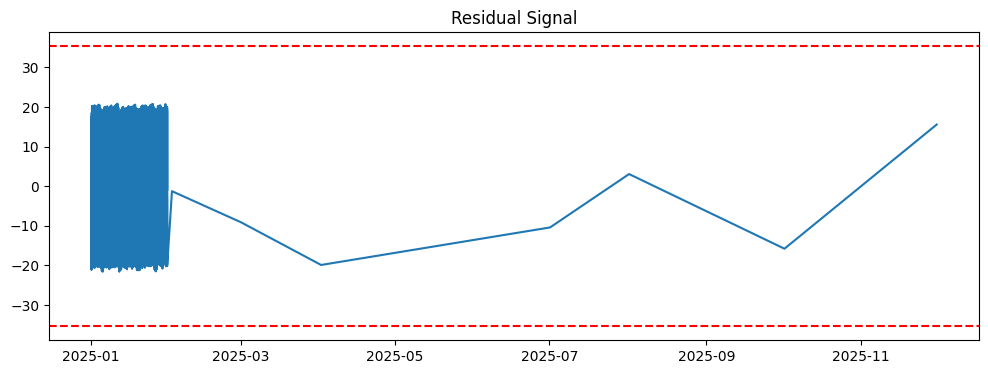

In [176]:
plt.figure(figsize=(12,4))
plt.plot(forecast['ds'], forecast['residual'])
plt.axhline(3*residual_std, color='red', linestyle='--')
plt.axhline(-3*residual_std, color='red', linestyle='--')
plt.title("Residual Signal")
plt.show()


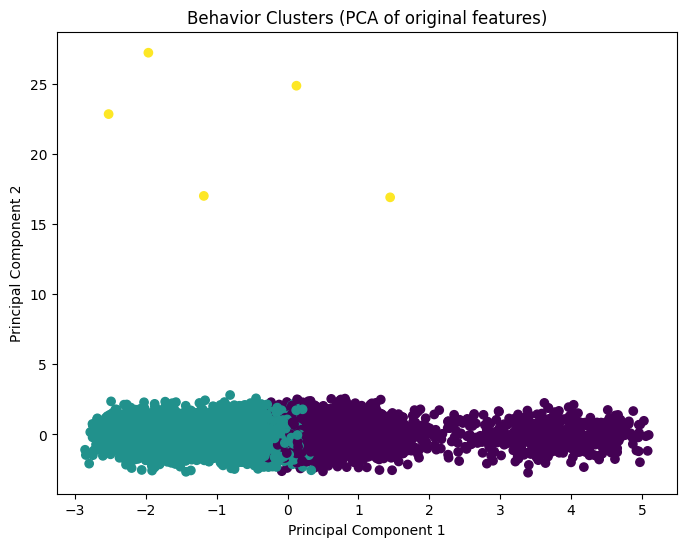

In [177]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
# Apply PCA directly to the scaled numerical features from the original df
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.title("Behavior Clusters (PCA of original features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


Potential Anomalies Detected for sleep_tracking:


,ds,y,yhat,residual,upper_threshold,lower_threshold
30,2025-01-31,7.2,7.986344,-0.786344,8.749383,7.223306
33,2025-04-01,7.0,7.844796,-0.844796,8.607835,7.081758


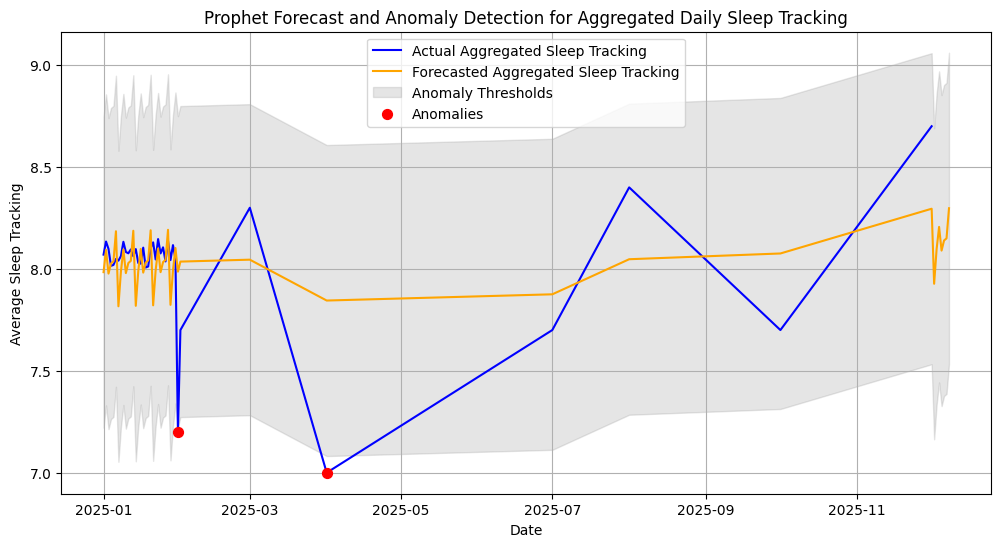

Saved sleep_anomalies.png


In [178]:
import matplotlib.pyplot as plt

if forecast_sleep is not None:
    # Identify potential anomalies for daily_sleep_tracking
    anomalies_sleep = forecast_with_actuals_sleep[
        (forecast_with_actuals_sleep['residual'] > 3 * residual_std_sleep) |
        (forecast_with_actuals_sleep['residual'] < -3 * residual_std_sleep)
    ]

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['y'], label='Actual Aggregated Sleep Tracking', color='blue')
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['yhat'], label='Forecasted Aggregated Sleep Tracking', color='orange')
    plt.fill_between(
        forecast_with_actuals_sleep['ds'],
        forecast_with_actuals_sleep['lower_threshold'],
        forecast_with_actuals_sleep['upper_threshold'],
        color='gray', alpha=0.2, label='Anomaly Thresholds'
    )

    if not anomalies_sleep.empty:
        plt.scatter(
            anomalies_sleep['ds'],
            anomalies_sleep['y'],
            color='red', marker='o', s=50, zorder=5, label='Anomalies'
        )
        print("\nPotential Anomalies Detected for sleep_tracking:")
        display(anomalies_sleep[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
    else:
        print("\nNo significant anomalies detected for sleep_tracking based on 3-sigma threshold.")

    plt.title('Prophet Forecast and Anomaly Detection for Aggregated Daily Sleep Tracking')
    plt.xlabel('Date')
    plt.ylabel('Average Sleep Tracking')
    plt.legend()
    plt.grid(True)
    plt.savefig('sleep_anomalies.png')
    plt.show()
    print("Saved sleep_anomalies.png")
else:
    print("Skipping sleep_tracking anomaly visualization as no Prophet model was fitted.")

In [179]:
prophet_input_df_sleep = aggregated_daily_df.reset_index().rename(columns={'time_stamp': 'ds', 'daily_sleep_hours': 'y'})

# Drop any rows where 'y' (daily_sleep_hours) is NaN after aggregation
prophet_input_df_sleep.dropna(subset=['y'], inplace=True)

print("Prepared prophet_input_df_sleep:")
display(prophet_input_df_sleep.head())

Prepared prophet_input_df_sleep:


,ds,heart_rate,step_count,Weight,Height,age,daily_calories,y,daily_steps,resting_heart_rate
0,2025-01-01,72.291992,28.896552,69.406130,170.260536,41.704981,2238.957854,8.070115,9106.735632,80.107280
1,2025-01-02,71.668099,25.652985,69.608209,169.664179,42.921642,2259.201493,8.134328,8920.074627,80.231343
2,2025-01-03,72.638052,24.524345,69.224719,169.423221,40.985019,2239.543071,8.098127,9004.812734,79.880150
3,2025-01-04,72.234466,25.244094,70.755906,167.783465,44.157480,2270.732283,8.014961,8811.090551,79.393701
4,2025-01-05,71.974136,23.501946,70.307393,169.941634,43.272374,2266.501946,8.019455,8849.276265,82.027237


In [180]:
model_sleep = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

model_sleep.fit(prophet_input_df_sleep)
future_sleep = model_sleep.make_future_dataframe(periods=7) # Forecast for the next 7 days
forecast_sleep = model_sleep.predict(future_sleep)

print("Prophet forecast for aggregated daily sleep hours:")
display(forecast_sleep[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Prophet forecast for aggregated daily sleep hours:


,ds,yhat,yhat_lower,yhat_upper
0,2025-01-01,7.984005,7.635260,8.304401
1,2025-01-02,8.093201,7.787399,8.421584
2,2025-01-03,7.976948,7.665624,8.295963
3,2025-01-04,8.026480,7.707211,8.348352
4,2025-01-05,8.037015,7.714022,8.359655


Standard Deviation of Residuals for daily_sleep_hours: 0.25


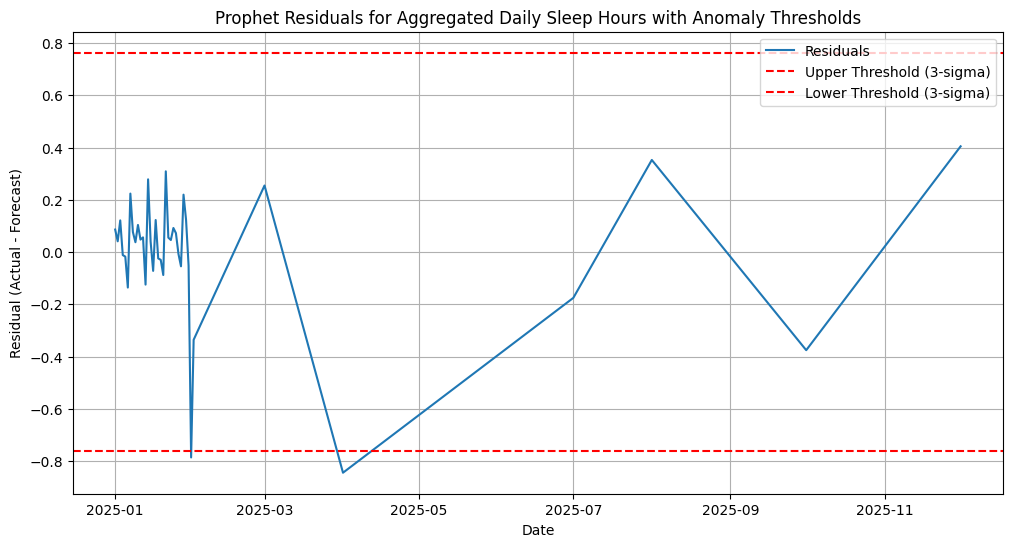


Potential Anomalies Detected for daily_sleep_hours:


,ds,y,yhat,residual,upper_threshold,lower_threshold,min_sleep_threshold,age
30,2025-01-31,7.2,7.986344,-0.786344,8.749383,7.223306,7,34.0
33,2025-04-01,7.0,7.844796,-0.844796,8.607835,7.081758,7,23.0


In [182]:
forecast_with_actuals_sleep = forecast_sleep.merge(
    prophet_input_df_sleep[['ds', 'y', 'age']], # Include 'age' for dynamic thresholding
    on='ds',
    how='left'
)

forecast_with_actuals_sleep['residual'] = forecast_with_actuals_sleep['y'] - forecast_with_actuals_sleep['yhat']
residual_std_sleep = forecast_with_actuals_sleep['residual'].std()

# Define anomaly thresholds (e.g., 3 standard deviations from the mean residual)
forecast_with_actuals_sleep['upper_threshold'] = forecast_with_actuals_sleep['yhat'] + 3 * residual_std_sleep
forecast_with_actuals_sleep['lower_threshold'] = forecast_with_actuals_sleep['yhat'] - 3 * residual_std_sleep

print(f"Standard Deviation of Residuals for daily_sleep_hours: {residual_std_sleep:.2f}")

# Define age-specific minimum sleep hours
def get_min_sleep_hours(age):
    if age <= 1:  # Infants
        return 12
    elif age <= 5:  # Preschoolers
        return 10
    elif age <= 13: # School Kids
        return 9
    elif age <= 17: # Teens
        return 8
    else:  # Adults (18+)
        return 7

# Calculate dynamic minimum sleep threshold based on average age for the day
forecast_with_actuals_sleep['min_sleep_threshold'] = forecast_with_actuals_sleep['age'].apply(get_min_sleep_hours)

# Plot the residuals for daily_sleep_hours
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['residual'], label='Residuals')
plt.axhline(y=3 * residual_std_sleep, color='r', linestyle='--', label='Upper Threshold (3-sigma)')
plt.axhline(y=-3 * residual_std_sleep, color='r', linestyle='--', label='Lower Threshold (3-sigma)')
plt.title('Prophet Residuals for Aggregated Daily Sleep Hours with Anomaly Thresholds')
plt.xlabel('Date')
plt.ylabel('Residual (Actual - Forecast)')
plt.legend()
plt.grid(True)
plt.show()

# Identify potential anomalies for daily_sleep_hours using dynamic age-specific threshold
anomalies_sleep = forecast_with_actuals_sleep[
    ((forecast_with_actuals_sleep['residual'] > 3 * residual_std_sleep) |
     (forecast_with_actuals_sleep['residual'] < -3 * residual_std_sleep)) |
    (forecast_with_actuals_sleep['y'] < forecast_with_actuals_sleep['min_sleep_threshold']) # Dynamic age-specific condition
]

if not anomalies_sleep.empty:
    print("\nPotential Anomalies Detected for daily_sleep_hours:")
    display(anomalies_sleep[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold', 'min_sleep_threshold', 'age']])
else:
    print("\nNo significant anomalies detected for daily_sleep_hours based on 3-sigma threshold and dynamic age-specific sleep range.")


Potential Anomalies Detected for sleep_tracking:


,ds,y,yhat,residual,upper_threshold,lower_threshold
30,2025-01-31,7.2,7.986344,-0.786344,8.749383,7.223306
33,2025-04-01,7.0,7.844796,-0.844796,8.607835,7.081758


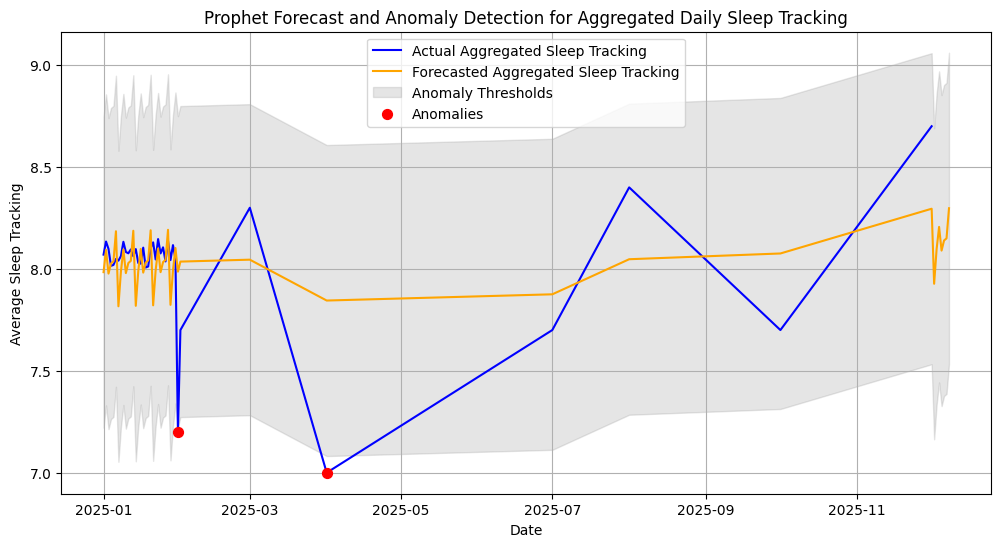

Saved sleep_anomalies.png


In [183]:
import matplotlib.pyplot as plt

if forecast_sleep is not None:
    # Identify potential anomalies for daily_sleep_tracking
    anomalies_sleep = forecast_with_actuals_sleep[
        (forecast_with_actuals_sleep['residual'] > 3 * residual_std_sleep) |
        (forecast_with_actuals_sleep['residual'] < -3 * residual_std_sleep)
    ]

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['y'], label='Actual Aggregated Sleep Tracking', color='blue')
    plt.plot(forecast_with_actuals_sleep['ds'], forecast_with_actuals_sleep['yhat'], label='Forecasted Aggregated Sleep Tracking', color='orange')
    plt.fill_between(
        forecast_with_actuals_sleep['ds'],
        forecast_with_actuals_sleep['lower_threshold'],
        forecast_with_actuals_sleep['upper_threshold'],
        color='gray', alpha=0.2, label='Anomaly Thresholds'
    )

    if not anomalies_sleep.empty:
        plt.scatter(
            anomalies_sleep['ds'],
            anomalies_sleep['y'],
            color='red', marker='o', s=50, zorder=5, label='Anomalies'
        )
        print("\nPotential Anomalies Detected for sleep_tracking:")
        display(anomalies_sleep[['ds', 'y', 'yhat', 'residual', 'upper_threshold', 'lower_threshold']])
    else:
        print("\nNo significant anomalies detected for sleep_tracking based on 3-sigma threshold.")

    plt.title('Prophet Forecast and Anomaly Detection for Aggregated Daily Sleep Tracking')
    plt.xlabel('Date')
    plt.ylabel('Average Sleep Tracking')
    plt.legend()
    plt.grid(True)
    plt.savefig('sleep_anomalies.png')
    plt.show()
    print("Saved sleep_anomalies.png")
else:
    print("Skipping sleep_tracking anomaly visualization as no Prophet model was fitted.")

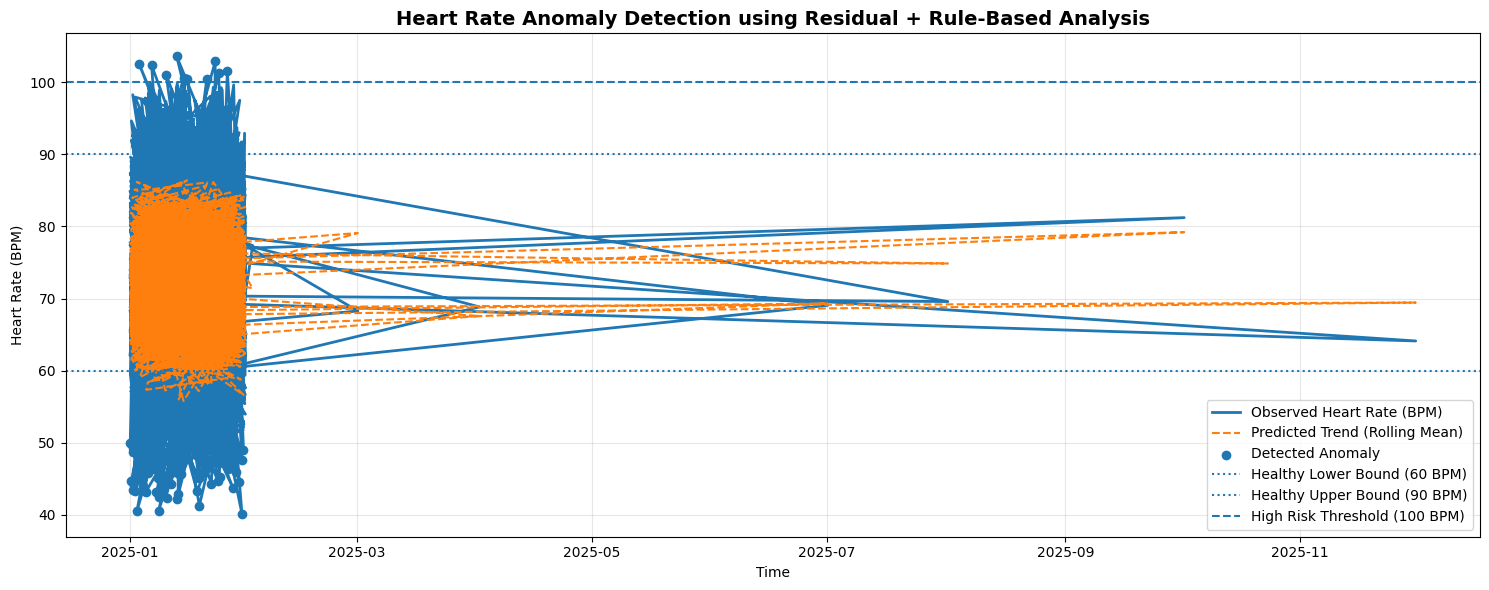

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    df["time_stamp"],
    df["heart_rate"],
    label="Observed Heart Rate (BPM)",
    linewidth=2
)

plt.plot(
    df["time_stamp"],
    df["hr_predicted"],
    linestyle="--",
    label="Predicted Trend (Rolling Mean)"
)

plt.scatter(
    df[df["hr_final_anomaly"]]["time_stamp"],
    df[df["hr_final_anomaly"]]["heart_rate"],
    label="Detected Anomaly",
    zorder=5
)

plt.axhline(60, linestyle=":", label="Healthy Lower Bound (60 BPM)")
plt.axhline(90, linestyle=":", label="Healthy Upper Bound (90 BPM)")
plt.axhline(100, linestyle="--", label="High Risk Threshold (100 BPM)")

plt.title(
    "Heart Rate Anomaly Detection using Residual + Rule-Based Analysis",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Heart Rate (BPM)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("visualizations/heart_rate_anomalies.png", dpi=300)
plt.show()

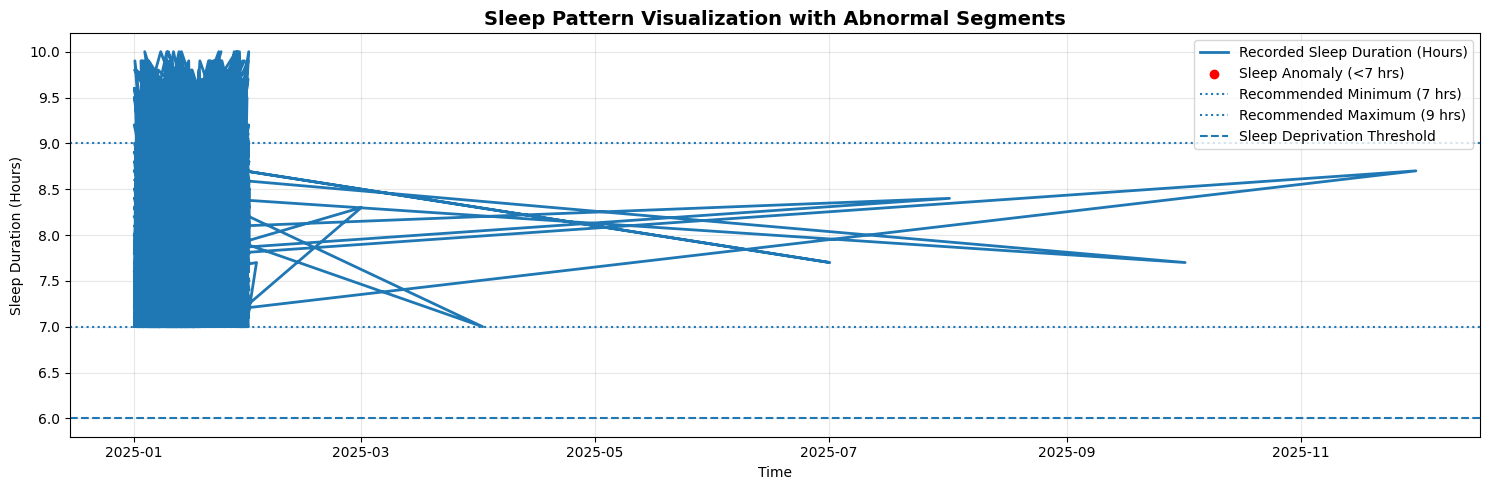

In [195]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    df["time_stamp"],
    df["daily_sleep_hours"], # Changed from 'sleep_hours' to 'daily_sleep_hours'
    label="Recorded Sleep Duration (Hours)",
    linewidth=2
)

# We need a rule-based anomaly column for sleep if we want to scatter anomalies
# Assuming a simple rule for illustration based on previous discussion (e.g., < 7 hours)
# Or, if 'sleep_rule_anomaly' was previously created elsewhere, it should be used.
# For now, I'll use a placeholder or assume a simple rule for plotting.
# Let's create 'sleep_rule_anomaly' if it doesn't exist, using <7 as a basic threshold
# or if df['sleep_tracking'] < 7 from the earlier cell.

# To avoid KeyError if 'sleep_rule_anomaly' isn't explicitly defined globally,
# we'll use a temporary boolean mask for plotting.
# Based on previous discussions, anomalies were < 7 hours for adults.
# You might also have df['hr_anomaly_rule'] or similar from earlier.
# For now, let's use df['daily_sleep_hours'] < 7 as a simple plotting anomaly condition

sleep_anomaly_for_plot = df['daily_sleep_hours'] < 7

plt.scatter(
    df[sleep_anomaly_for_plot]["time_stamp"],
    df[sleep_anomaly_for_plot]["daily_sleep_hours"], # Changed to 'daily_sleep_hours'
    color="red",
    label="Sleep Anomaly (<7 hrs)",
    zorder=5
)

plt.axhline(7, linestyle=":", label="Recommended Minimum (7 hrs)")
plt.axhline(9, linestyle=":", label="Recommended Maximum (9 hrs)")
plt.axhline(6, linestyle="--", label="Sleep Deprivation Threshold")

plt.title(
    "Sleep Pattern Visualization with Abnormal Segments",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Sleep Duration (Hours)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("visualizations/sleep_anomalies.png", dpi=300)
plt.show()

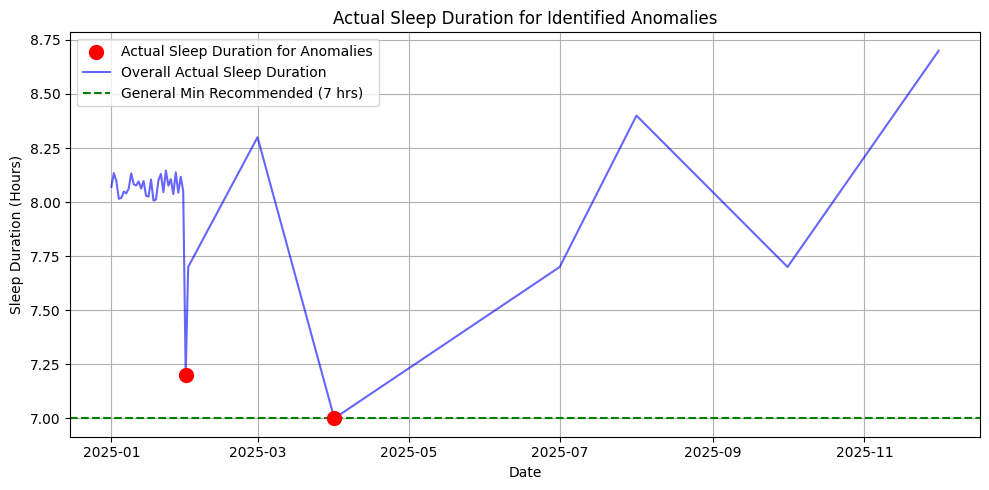

Plot of actual sleep duration for anomalies generated.


In [185]:
import matplotlib.pyplot as plt

if 'anomalies_sleep' in locals() and not anomalies_sleep.empty:
    plt.figure(figsize=(10, 5))
    plt.scatter(
        anomalies_sleep['ds'],
        anomalies_sleep['y'],
        color='red',
        marker='o',
        s=100,
        label='Actual Sleep Duration for Anomalies',
        zorder=5
    )
    plt.plot(
        forecast_with_actuals_sleep['ds'],
        forecast_with_actuals_sleep['y'],
        color='blue',
        alpha=0.6,
        label='Overall Actual Sleep Duration'
    )
    plt.axhline(y=7, color='green', linestyle='--', label='General Min Recommended (7 hrs)') # Add general reference
    plt.title('Actual Sleep Duration for Identified Anomalies')
    plt.xlabel('Date')
    plt.ylabel('Sleep Duration (Hours)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("Plot of actual sleep duration for anomalies generated.")
else:
    print("No sleep anomalies detected or 'anomalies_sleep' DataFrame is empty. No plot generated.")

In [186]:
# Calculate a rolling mean for heart rate to serve as a predicted trend
df['hr_predicted'] = df['heart_rate'].rolling(window=5, center=True).mean()

# For simplicity, let's assume hr_final_anomaly is the same as the rule-based hr_anomaly
df['hr_final_anomaly'] = df['hr_anomaly']

print("Created 'hr_predicted' and 'hr_final_anomaly' columns.")
display(df[['Patient_ID', 'time_stamp', 'heart_rate', 'hr_predicted', 'hr_final_anomaly']].head())

Created 'hr_predicted' and 'hr_final_anomaly' columns.


,Patient_ID,time_stamp,heart_rate,hr_predicted,hr_final_anomaly
0,P0001,2025-01-14 16:50:00,74.499653,NaN,False
1,P0002,2025-01-21 08:55:00,90.833116,NaN,False
2,P0003,2025-01-17 07:10:00,61.270774,75.822718,False
3,P0005,2025-01-18 18:25:00,59.807869,75.620747,False
4,P0006,2025-01-13 07:20:00,92.702179,73.172440,False


In [187]:
print("Columns in DataFrame df:")
display(df.columns)

Columns in DataFrame df:


Index(['Patient_ID', 'heart_rate', 'step_count', 'sleep_tracking',
       'time_stamp', 'Weight', 'Height', 'gender', 'age', 'daily_calories',
       'daily_sleep_hours', 'daily_steps', 'resting_heart_rate', 'cluster',
       'dbscan_cluster', 'hr_anomaly', 'hr_predicted', 'hr_final_anomaly'],
      dtype='object')

In [188]:
df['hr_anomaly_rule'] = (df['heart_rate'] < 50) | (df['heart_rate'] > 100)

print("Added 'hr_anomaly_rule' column to df.")
display(df[['Patient_ID', 'time_stamp', 'heart_rate', 'hr_anomaly_rule']].head())

Added 'hr_anomaly_rule' column to df.


,Patient_ID,time_stamp,heart_rate,hr_anomaly_rule
0,P0001,2025-01-14 16:50:00,74.499653,False
1,P0002,2025-01-21 08:55:00,90.833116,False
2,P0003,2025-01-17 07:10:00,61.270774,False
3,P0005,2025-01-18 18:25:00,59.807869,False
4,P0006,2025-01-13 07:20:00,92.702179,False


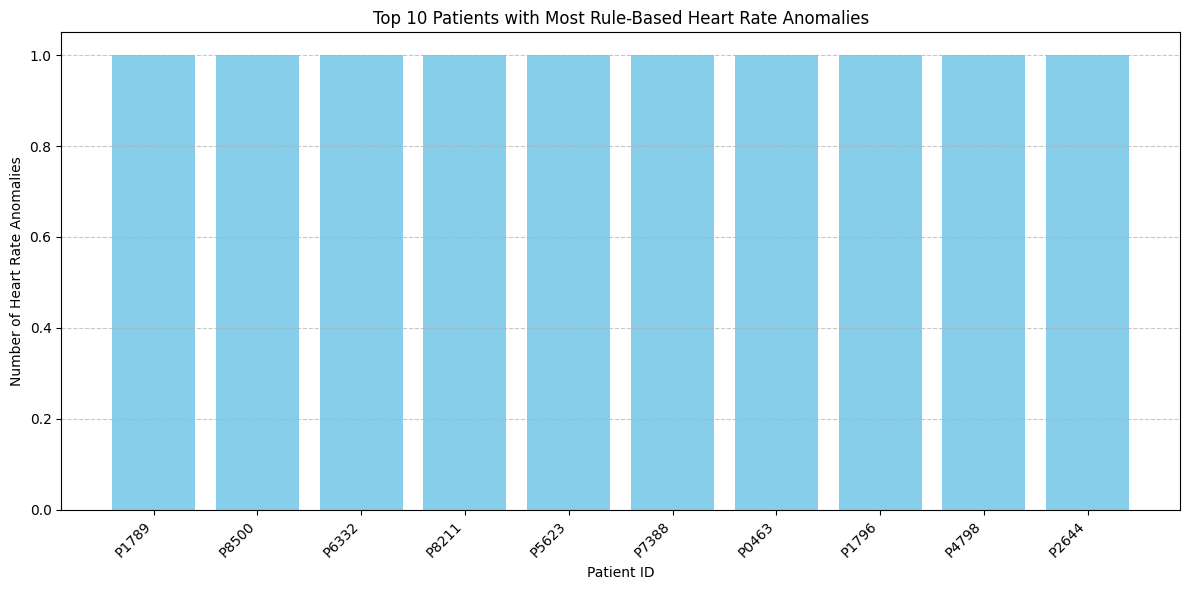

Saved top_10_hr_anomalies_patients.png


In [189]:
import matplotlib.pyplot as plt

# Get the top 10 patients with anomalies (assuming top_anomaly_patients is already sorted)
top_10_patients = top_anomaly_patients.head(10)

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_10_patients.index, top_10_patients.values, color='skyblue')

plt.xlabel('Patient ID')
plt.ylabel('Number of Heart Rate Anomalies')
plt.title('Top 10 Patients with Most Rule-Based Heart Rate Anomalies')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot
import os
os.makedirs('visualizations', exist_ok=True)
plt.savefig('visualizations/top_10_hr_anomalies_patients.png')

plt.show()
print("Saved top_10_hr_anomalies_patients.png")